In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Outputs/hotel_bookings_cleaned.csv")

In [3]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests,total_revenue,arrival_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,01-07-2015,0,2,0.00,01-Jul-15
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,01-07-2015,0,2,0.00,01-Jul-15
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,02-07-2015,1,1,75.00,01-Jul-15
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,02-07-2015,1,1,75.00,01-Jul-15
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.00,0,1,Check-Out,03-07-2015,2,2,196.00,01-Jul-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84884,City Hotel,0,23,2017,August,35,30,2,5,2,...,Transient,96.14,0,0,Check-Out,06-09-2017,7,2,672.98,30-Aug-17
84885,City Hotel,0,102,2017,August,35,31,2,5,3,...,Transient,225.43,0,2,Check-Out,07-09-2017,7,3,1578.01,31-Aug-17
84886,City Hotel,0,34,2017,August,35,31,2,5,2,...,Transient,157.71,0,4,Check-Out,07-09-2017,7,2,1103.97,31-Aug-17
84887,City Hotel,0,109,2017,August,35,31,2,5,2,...,Transient,104.40,0,0,Check-Out,07-09-2017,7,2,730.80,31-Aug-17


In [4]:
df.shape

(84889, 36)

In [5]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests,total_revenue,arrival_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,01-07-2015,0,2,0.0,01-Jul-15
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,01-07-2015,0,2,0.0,01-Jul-15
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,02-07-2015,1,1,75.0,01-Jul-15
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,02-07-2015,1,1,75.0,01-Jul-15
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,03-07-2015,2,2,196.0,01-Jul-15


**Cancellation Rate Analysis**

([<matplotlib.axis.XTick at 0x2ab2f589940>,
 [Text(0, 0, 'Not Canceled'), Text(1, 0, 'Canceled')])

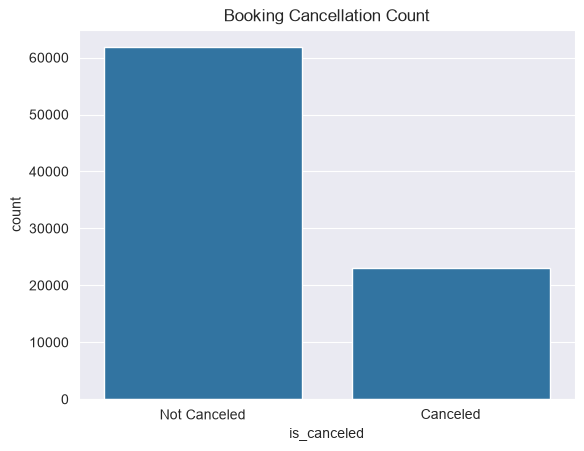

In [6]:
df['is_canceled'].value_counts()
df['is_canceled'].value_counts(normalize=True) * 100

sns.countplot(x='is_canceled', data=df)
plt.title('Booking Cancellation Count')
plt.xticks([0,1], ['Not Canceled', 'Canceled'])

### Finding: Cancellation Rate Analysis
- Approximately 32% of total bookings were canceled
- Out of 84,889 bookings, around 28,000 were canceled
- This is a significant revenue loss for the hotel
- Reducing cancellation rate should be top priority


**ADR vs Cancellation**

([<matplotlib.axis.XTick at 0x2ab2f7ead50>,
 [Text(0, 0, 'Not Canceled'), Text(1, 0, 'Canceled')])

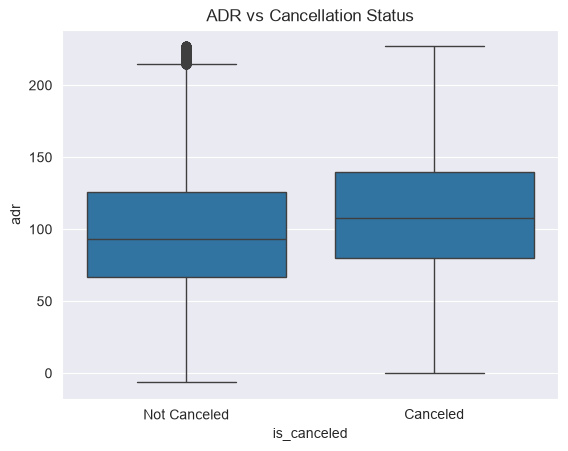

In [7]:
sns.boxplot(x='is_canceled', y='adr', data=df)
plt.title('ADR vs Cancellation Status')
plt.xticks([0,1], ['Not Canceled', 'Canceled'])

### Finding: ADR vs Cancellation
- Canceled bookings have slightly higher ADR
- Expensive room bookings have higher cancellation risk
- Median ADR of canceled bookings is around 115
- Median ADR of non-canceled bookings is around 100
- Hotels should apply stricter policies for high ADR bookings

 Lead Time vs Cancellation

Text(0, 0.5, 'Count')

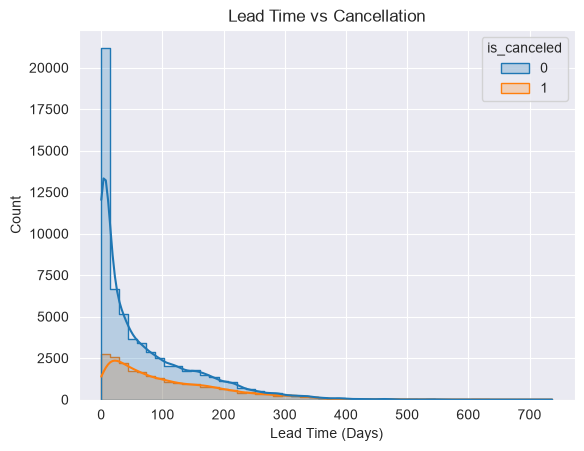

In [8]:
sns.histplot(data=df, x='lead_time',
             hue='is_canceled',
             bins=50, kde=True,
             element='step')
plt.title('Lead Time vs Cancellation')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Count')

### Finding: Lead Time vs Cancellation
- Higher lead time means higher cancellation probability
- Customers who book very early tend to cancel more
- Last minute bookings have lower cancellation rate
- Lead time is a strong predictor for cancellation

 Seasonal ADR Trend

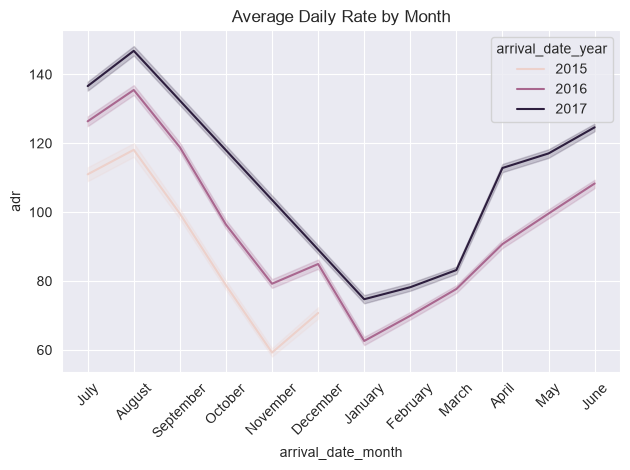

In [9]:
sns.lineplot(data=df,
             x='arrival_date_month',
             y='adr',
             hue='arrival_date_year')
plt.title('Average Daily Rate by Month')
plt.xticks(rotation=45)
plt.tight_layout()

### Finding: Seasonal ADR Trend
- ADR is highest during summer months (June, July, August)
- Winter months have comparatively lower ADR
- Peak season shows highest demand and pricing
- Hotels should plan dynamic pricing based on seasonality

Correlation Heatmap

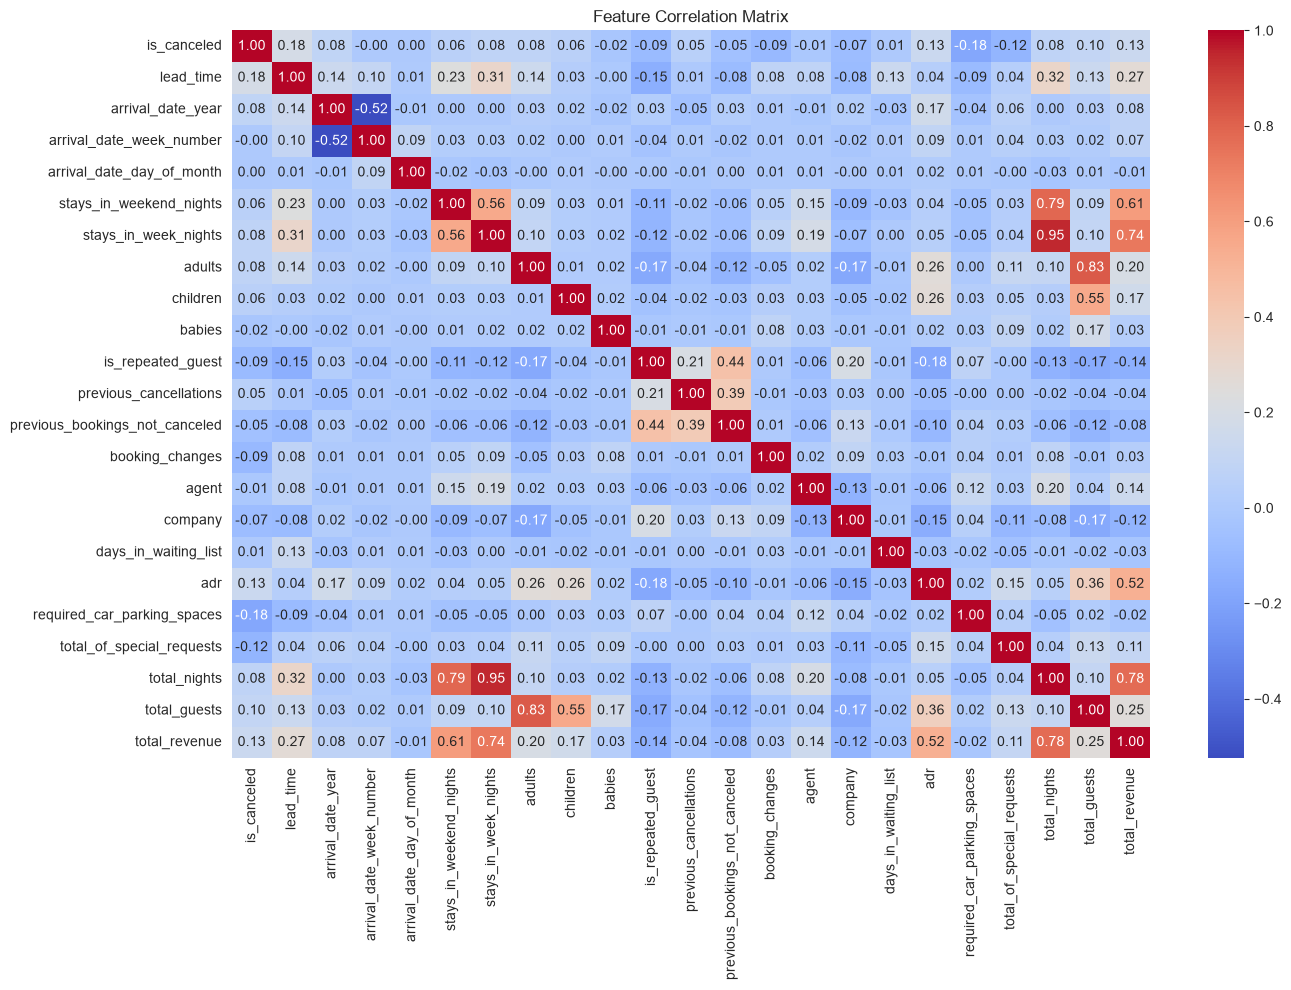

In [10]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True,
            fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()


### Finding: Correlation Heatmap
- Lead time has positive correlation with cancellation
- Previous cancellations strongly predict future cancellations
- ADR and total revenue have strong positive correlation
- Required car parking spaces has low correlation with cancellation

Customer Segmentation

Text(0.5, 1.0, 'Cancellation by Deposit Type')

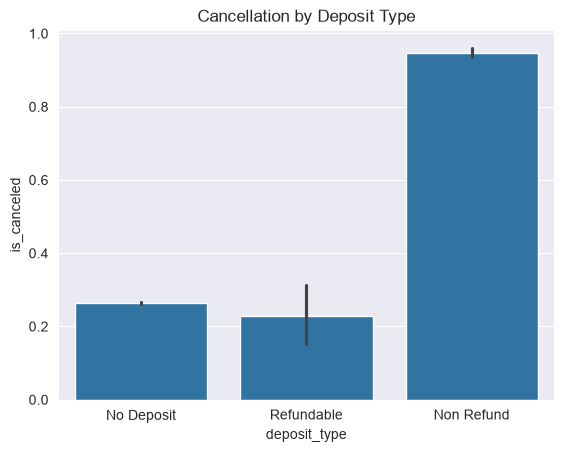

In [11]:
sns.barplot(x='deposit_type',
            y='is_canceled', data=df)
plt.title('Cancellation by Deposit Type')

### Finding: Cancellation by Deposit Type
- Non-refundable deposit bookings almost never cancel
- No deposit bookings have highest cancellation rate
- Deposit type is one of the strongest cancellation predictors
- Hotels should encourage non-refundable deposit policies

Text(0.5, 1.0, 'Cancellation by Customer Type')

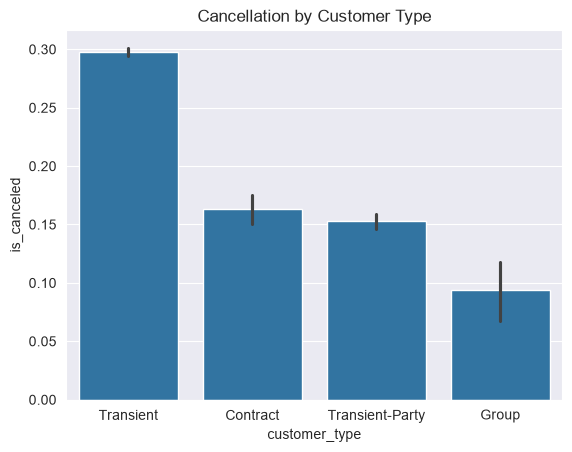

In [12]:
sns.barplot(x='customer_type',
            y='is_canceled', data=df)
plt.title('Cancellation by Customer Type')

### Finding: Cancellation by Customer Type
- Transient customers have highest cancellation rate
- Contract customers have lowest cancellation rate
- Group bookings have moderate cancellation rate
- Transient customers need special retention strategies

Text(0.5, 1.0, 'Cancellation by Hotel Type')

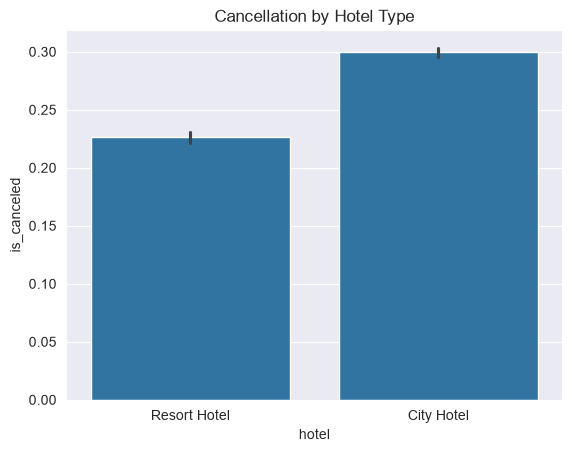

In [13]:
sns.barplot(x='hotel',
            y='is_canceled', data=df)
plt.title('Cancellation by Hotel Type')

### Finding: Cancellation by Hotel Type
- City Hotel has higher cancellation rate than Resort Hotel
- Resort Hotel guests tend to be more committed to their bookings
- City Hotel needs stronger cancellation prevention strategies

In [14]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df['deposit_type'], df['is_canceled'])
chi2, p_value, dof, expected = chi2_contingency(ct)

print("Chi-Square Test: Deposit Type vs Cancellation")
print(f"Chi2 value: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Significant relationship exists!")
else:
    print("Result: No significant relationship")

Chi-Square Test: Deposit Type vs Cancellation
Chi2 value: 2416.5869
P-value: 0.0000
Result: Significant relationship exists!


In [15]:
from scipy.stats import pointbiserialr

# Lead time vs Cancellation
corr, p_value = pointbiserialr(df['lead_time'],
                                df['is_canceled'])

print("Lead Time vs Cancellation")
print(f"Correlation: {corr:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Significant relationship exists!")
else:
    print("Result: No significant relationship")

Lead Time vs Cancellation
Correlation: 0.1849
P-value: 0.0000
Result: Significant relationship exists!


In [16]:
from scipy.stats import mannwhitneyu

canceled = df[df['is_canceled']==1]['adr']
not_canceled = df[df['is_canceled']==0]['adr']

stat, p_value = mannwhitneyu(canceled, not_canceled)

print("Mann Whitney U Test: ADR vs Cancellation")
print(f"Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: ADR difference is statistically significant!")
else:
    print("Result: No significant difference in ADR")

Mann Whitney U Test: ADR vs Cancellation
Statistic: 841083047.0000
P-value: 0.0000
Result: ADR difference is statistically significant!
